In [ ]:
!unzip -l "Cervical Cell Image Database.zip" | head -40

Archive:  Cervical Cell Image Database.zip
  Length      Date    Time    Name
---------  ---------- -----   ----
    14614  2026-05-11 09:29   carcinoma_in_situ/1.BMP
    28614  2026-05-11 09:29   carcinoma_in_situ/10.BMP
    56214  2026-05-11 09:29   carcinoma_in_situ/100.BMP
     2475  2026-05-11 09:28   carcinoma_in_situ/100INPUT.png
    16062  2026-05-11 09:29   carcinoma_in_situ/101.BMP
     2178  2026-05-11 09:28   carcinoma_in_situ/101INPUT.png
    15930  2026-05-11 09:29   carcinoma_in_situ/102.BMP
     2142  2026-05-11 09:28   carcinoma_in_situ/102INPUT.png
    11574  2026-05-11 09:29   carcinoma_in_situ/103.BMP
     1348  2026-05-11 09:28   carcinoma_in_situ/103INPUT.png
    22134  2026-05-11 09:29   carcinoma_in_situ/104.BMP
     2388  2026-05-11 09:28   carcinoma_in_situ/104INPUT.png
    19318  2026-05-11 09:29   carcinoma_in_situ/105.BMP
     2498  2026-05-11 09:28   carcinoma_in_situ/105INPUT.png
    18150  2026-05-11 09:29   carcinoma_in_situ/106.BMP
     1931  2026-05-1

In [ ]:
!mkdir -p /content/cervical_dataset
!unzip -q "Cervical Cell Image Database.zip" -d /content/cervical_dataset

In [ ]:
import os

print(os.listdir("/content/cervical_dataset"))

['normal_intermediate', 'carcinoma_in_situ', 'light_dysplastic', 'severe_dysplastic', 'moderate_dysplastic', 'normal_columnar', 'normal_superficiel']


In [ ]:
import os

for root, dirs, files in os.walk("/content/cervical_dataset"):
    print("FOLDER:", root)
    print("SUBFOLDERS:", dirs)
    print("FILES:", len(files))
    print("-" * 50)

FOLDER: /content/cervical_dataset
SUBFOLDERS: ['normal_superficiel', 'normal_intermediate', 'moderate_dysplastic', 'light_dysplastic', 'severe_dysplastic', 'carcinoma_in_situ', 'normal_columnar']
FILES: 0
--------------------------------------------------
FOLDER: /content/cervical_dataset/normal_superficiel
SUBFOLDERS: []
FILES: 148
--------------------------------------------------
FOLDER: /content/cervical_dataset/normal_intermediate
SUBFOLDERS: []
FILES: 140
--------------------------------------------------
FOLDER: /content/cervical_dataset/moderate_dysplastic
SUBFOLDERS: []
FILES: 292
--------------------------------------------------
FOLDER: /content/cervical_dataset/light_dysplastic
SUBFOLDERS: []
FILES: 364
--------------------------------------------------
FOLDER: /content/cervical_dataset/severe_dysplastic
SUBFOLDERS: []
FILES: 394
--------------------------------------------------
FOLDER: /content/cervical_dataset/carcinoma_in_situ
SUBFOLDERS: []
FILES: 300
-----------------

In [ ]:
import os

base = "/content/cervical_dataset"

for root, dirs, files in os.walk(base):
    image_files = [
        f for f in files
        if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
    ]

    if image_files:
        print(f"{root}  →  {len(image_files)} images")

/content/cervical_dataset/normal_superficiel  →  148 images
/content/cervical_dataset/normal_intermediate  →  140 images
/content/cervical_dataset/moderate_dysplastic  →  292 images
/content/cervical_dataset/light_dysplastic  →  364 images
/content/cervical_dataset/severe_dysplastic  →  394 images
/content/cervical_dataset/carcinoma_in_situ  →  300 images
/content/cervical_dataset/normal_columnar  →  196 images


In [ ]:
import os
import random
import shutil

random.seed(42)

source = "/content/cervical_dataset"
balanced = "/content/balanced_pap_smear"

# Create class folders
for cls in ["normal", "moderate", "severe"]:
    os.makedirs(os.path.join(balanced, cls), exist_ok=True)

# Correct folder names from YOUR dataset
normal_sources = [
    "normal_intermediate",
    "normal_columnar",
    "normal_superficiel"
]

moderate_source = "moderate_dysplastic"
severe_source = "severe_dysplastic"

# Collect normal images
normal_images = []

for folder in normal_sources:
    folder_path = os.path.join(source, folder)

    for file in os.listdir(folder_path):
        if file.lower().endswith((".bmp", ".jpg", ".jpeg", ".png")):
            normal_images.append(os.path.join(folder_path, file))

# Collect moderate images
moderate_images = [
    os.path.join(source, moderate_source, f)
    for f in os.listdir(os.path.join(source, moderate_source))
    if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
]

# Collect severe images
severe_images = [
    os.path.join(source, severe_source, f)
    for f in os.listdir(os.path.join(source, severe_source))
    if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
]

print("Available:")
print("Normal:", len(normal_images))
print("Moderate:", len(moderate_images))
print("Severe:", len(severe_images))

# Select exactly 292 from each class
normal_selected = random.sample(normal_images, 292)
moderate_selected = random.sample(moderate_images, 292)
severe_selected = random.sample(severe_images, 292)

# Copy images
for i, file in enumerate(normal_selected):
    shutil.copy(file, os.path.join(balanced, "normal", f"normal_{i}.bmp"))

for i, file in enumerate(moderate_selected):
    shutil.copy(file, os.path.join(balanced, "moderate", f"moderate_{i}.bmp"))

for i, file in enumerate(severe_selected):
    shutil.copy(file, os.path.join(balanced, "severe", f"severe_{i}.bmp"))

print("\nBalanced dataset created successfully!")

Available:
Normal: 484
Moderate: 292
Severe: 394

Balanced dataset created successfully!


In [ ]:
import os
import random
import shutil

random.seed(42)

source = "/content/balanced_pap_smear"

split_base = "/content/pap_smear_split"

# Create folders
for split in ["train", "val", "test"]:
    for cls in ["normal", "moderate", "severe"]:
        os.makedirs(os.path.join(split_base, split, cls), exist_ok=True)

# Split each class
for cls in ["normal", "moderate", "severe"]:

    files = [
        f for f in os.listdir(os.path.join(source, cls))
        if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
    ]

    random.shuffle(files)

    n = len(files)

    train_files = files[:int(0.70 * n)]
    val_files = files[int(0.70 * n):int(0.85 * n)]
    test_files = files[int(0.85 * n):]

    for f in train_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(split_base, "train", cls, f)
        )

    for f in val_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(split_base, "val", cls, f)
        )

    for f in test_files:
        shutil.copy(
            os.path.join(source, cls, f),
            os.path.join(split_base, "test", cls, f)
        )

print("Train / Validation / Test split completed!")

Train / Validation / Test split completed!


In [ ]:
import tensorflow as tf
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/pap_smear_split/train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/pap_smear_split/val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/pap_smear_split/test",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

print("Classes:", train_ds.class_names)

Found 612 files belonging to 3 classes.
Found 132 files belonging to 3 classes.
Found 132 files belonging to 3 classes.
Classes: ['moderate', 'normal', 'severe']


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.10),
    layers.RandomZoom(0.10),
    layers.RandomContrast(0.10)
])

def preprocess_dataset(images, labels):
    images = tf.cast(images, tf.float32)
    images = preprocess_input(images)
    return images, labels

# Augmentation ONLY for training
train_ds_aug = train_ds.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=tf.data.AUTOTUNE
)

train_ds_aug = train_ds_aug.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

val_ds_processed = val_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

test_ds_processed = test_ds.map(
    preprocess_dataset,
    num_parallel_calls=tf.data.AUTOTUNE
)

# Improve input pipeline speed
train_ds_aug = train_ds_aug.prefetch(tf.data.AUTOTUNE)
val_ds_processed = val_ds_processed.prefetch(tf.data.AUTOTUNE)
test_ds_processed = test_ds_processed.prefetch(tf.data.AUTOTUNE)

print("Preprocessing and augmentation ready!")
print("Classes:", train_ds.class_names)

Preprocessing and augmentation ready!
Classes: ['moderate', 'normal', 'severe']


In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# Load pretrained MobileNetV2
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Keep the pretrained feature extractor frozen initially
base_model.trainable = False

# Build classifier
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(3, activation="softmax")
])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
history = model.fit(
    train_ds_aug,
    validation_data=val_ds_processed,
    epochs=20,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 47s 1s/step - accuracy: 0.3709 - loss: 1.2471 - val_accuracy: 0.6667 - val_loss: 0.8187 - learning_rate: 1.0000e-04
Epoch 2/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.5539 - loss: 0.9527 - val_accuracy: 0.7348 - val_loss: 0.7016 - learning_rate: 1.0000e-04
Epoch 3/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.5850 - loss: 0.8561 - val_accuracy: 0.7273 - val_loss: 0.6579 - learning_rate: 1.0000e-04
Epoch 4/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6193 - loss: 0.8060 - val_accuracy: 0.7500 - val_loss: 0.6219 - learning_rate: 1.0000e-04
Epoch 5/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.6585 - loss: 0.7493 - val_accuracy: 0.7197 - val_loss: 0.6135 - learning_rate: 1.0000e-04
Epoch 6/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6520 - loss: 0.7465 - val_accuracy: 0.7576 - val_loss: 0.5886 - learning_rate: 1.0000e-04
Epoch 7/20
39/39 ━━━━━━━━━━━━━━━━━━━━ 44s 1s/step - accuracy: 0.6797 - loss:

In [ ]:
test_loss, test_accuracy = model.evaluate(test_ds_processed)

print("Test Accuracy:", test_accuracy)
print("Test Loss:", test_loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 492ms/step - accuracy: 0.6515 - loss: 0.6888
Test Accuracy: 0.6515151262283325
Test Loss: 0.6888111233711243


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

y_true = []
y_pred = []

for images, labels in test_ds_processed:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names
))

              precision    recall  f1-score   support

    moderate       0.65      0.64      0.64        44
      normal       0.93      0.61      0.74        44
      severe       0.52      0.70      0.60        44

    accuracy                           0.65       132
   macro avg       0.70      0.65      0.66       132
weighted avg       0.70      0.65      0.66       132



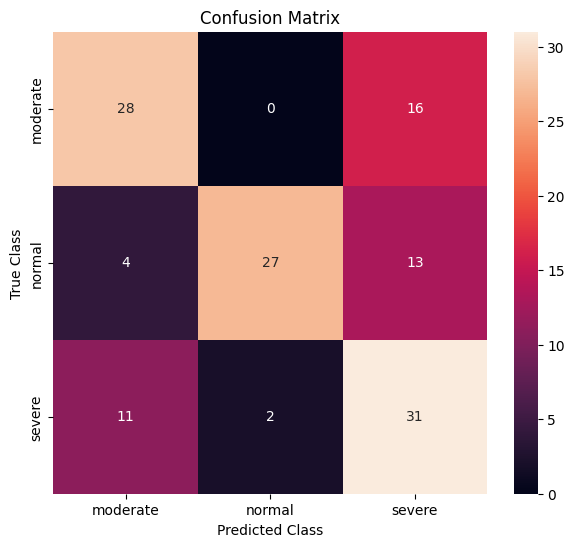

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_ds.class_names,
    yticklabels=train_ds.class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import os

for cls in ["normal", "moderate", "severe"]:
    folder = f"/content/pap_smear_split/test/{cls}"
    files = [
        f for f in os.listdir(folder)
        if f.lower().endswith((".bmp", ".jpg", ".jpeg", ".png"))
    ]
    print(cls, "→", files[0])

normal → normal_24.bmp
moderate → moderate_43.bmp
severe → severe_36.bmp


In [ ]:
import numpy as np
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

img_path = "/content/cervical_dataset/moderate_dysplastic/103.BMP"

img = load_img(img_path, target_size=(224, 224))
img_array = img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)

img_array = preprocess_input(img_array)

prediction = model.predict(img_array, verbose=0)

classes = train_ds.class_names

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction) * 100

print("Model Prediction:", predicted_class)
print("Confidence:", f"{confidence:.2f}%")

Model Prediction: moderate
Confidence: 74.10%


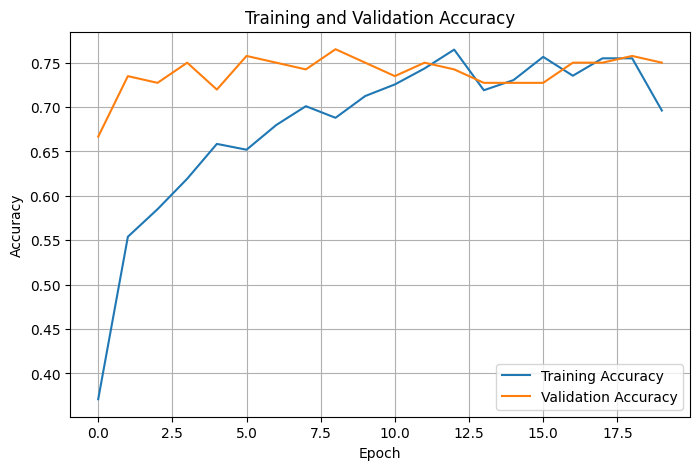

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

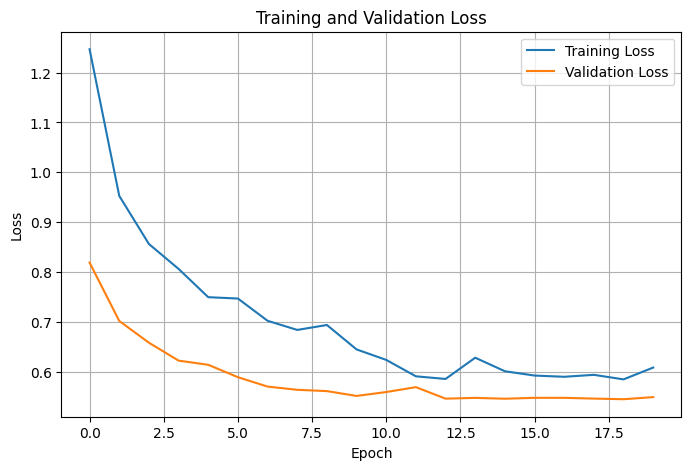

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    y_true,
    y_pred,
    target_names=train_ds.class_names,
    digits=2
))

              precision    recall  f1-score   support

    moderate       0.65      0.64      0.64        44
      normal       0.93      0.61      0.74        44
      severe       0.52      0.70      0.60        44

    accuracy                           0.65       132
   macro avg       0.70      0.65      0.66       132
weighted avg       0.70      0.65      0.66       132

